# Auto Street Lane Detection from a Single Image

This notebook detects road lane lines from the image:

`dataset/best/img00001.jpg`

We will use a classic computer vision pipeline:
1. Load and inspect image
2. Edge detection (Canny)
3. Region of interest masking
4. Hough line transform
5. Lane line averaging and overlay

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.grid'] = False

## 1) Load the input image

We read the image from disk, convert it to RGB for visualization, and display it.

Loaded: dataset/best/img00001.jpg
Shape: (540, 960, 3)


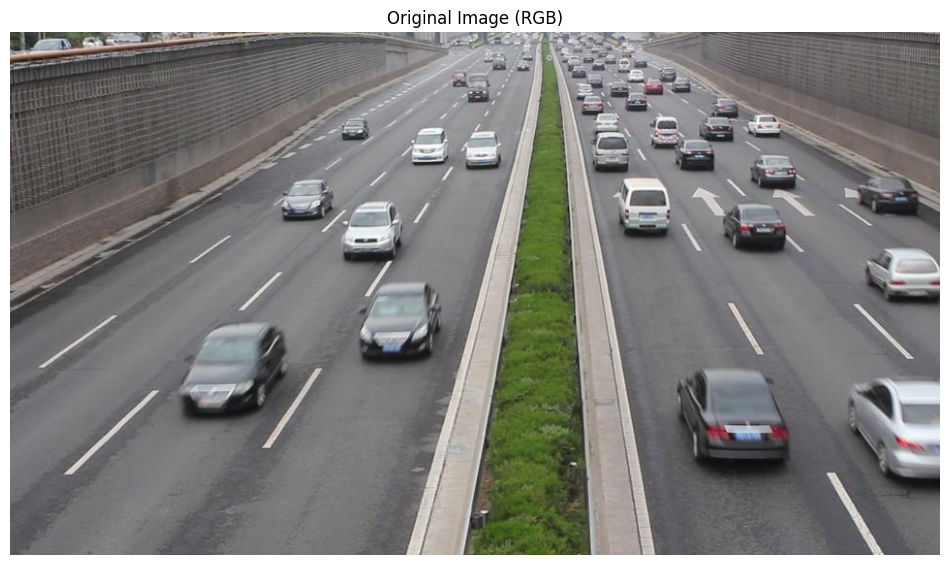

In [2]:
image_path = Path('dataset/best/img00001.jpg')

if not image_path.exists():
    raise FileNotFoundError(f'Image not found: {image_path.resolve()}')

image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise ValueError(f'Failed to read image: {image_path.resolve()}')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
height, width = image_rgb.shape[:2]

print(f'Loaded: {image_path}')
print(f'Shape: {image_rgb.shape}')

plt.figure()
plt.imshow(image_rgb)
plt.title('Original Image (RGB)')
plt.axis('off')
plt.show()

## 2) Preprocess image and detect edges

Convert to grayscale, smooth noise using Gaussian blur, then detect edges with Canny.

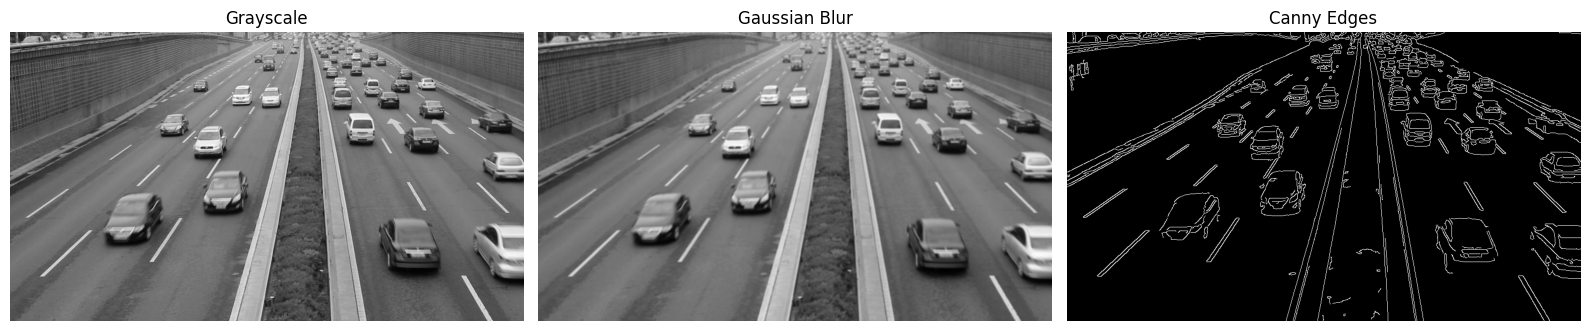

In [3]:
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blur, cmap='gray')
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

## 3) Focus on road region (ROI)

Mask the edge map to keep only the lower road area where lane lines usually appear.

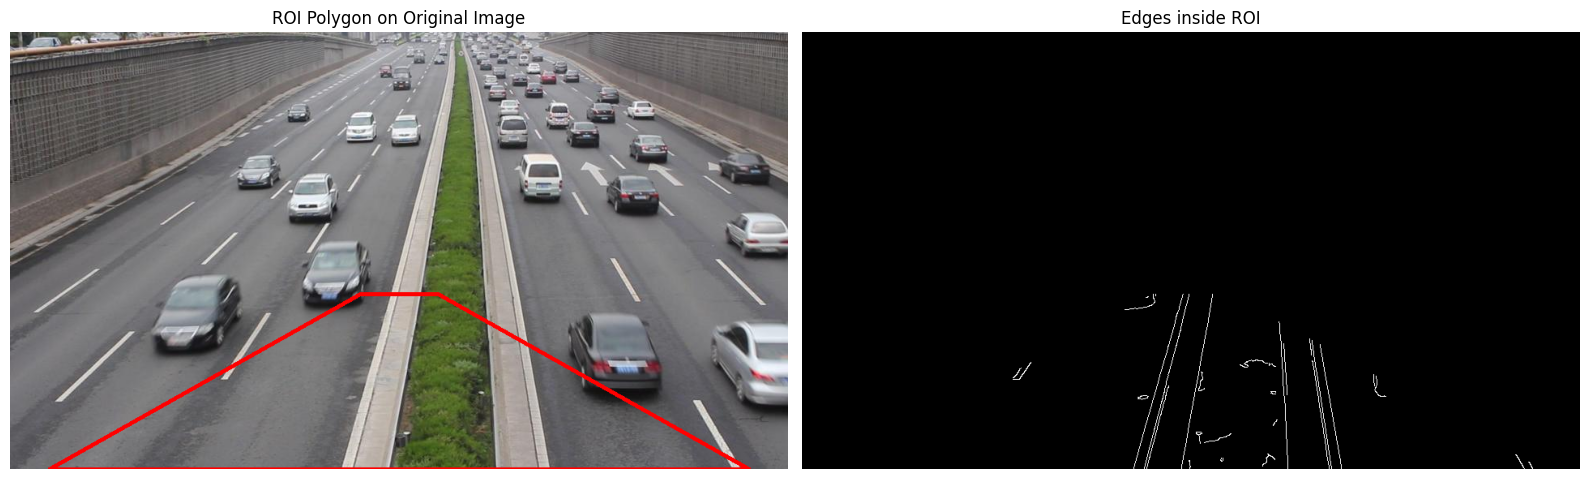

In [4]:
def region_of_interest(edge_image):
    h, w = edge_image.shape
    mask = np.zeros_like(edge_image)

    polygon = np.array([
        [
            (int(0.05 * w), h),
            (int(0.45 * w), int(0.60 * h)),
            (int(0.55 * w), int(0.60 * h)),
            (int(0.95 * w), h),
        ]
    ], dtype=np.int32)

    cv2.fillPoly(mask, polygon, 255)
    masked = cv2.bitwise_and(edge_image, mask)
    return masked, polygon

roi_edges, roi_polygon = region_of_interest(edges)

roi_preview = image_rgb.copy()
cv2.polylines(roi_preview, roi_polygon, isClosed=True, color=(255, 0, 0), thickness=3)

plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.imshow(roi_preview)
plt.title('ROI Polygon on Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(roi_edges, cmap='gray')
plt.title('Edges inside ROI')
plt.axis('off')

plt.tight_layout()
plt.show()

## 4) Detect lane lines with Hough Transform

Use probabilistic Hough transform to detect line segments, then average them into left and right lane lines.

In [5]:
def make_points(image, line_params):
    slope, intercept = line_params
    y1 = image.shape[0]
    y2 = int(y1 * 0.60)

    if abs(slope) < 1e-5:
        return None

    x1 = int((y1 - intercept) / slope)
    x2 = int((y2 - intercept) / slope)
    return np.array([x1, y1, x2, y2])


def average_lane_lines(image, lines):
    left_fit = []
    right_fit = []

    if lines is None:
        return []

    for line in lines:
        x1, y1, x2, y2 = line.reshape(4)
        if x2 == x1:
            continue

        slope, intercept = np.polyfit((x1, x2), (y1, y2), 1)

        if slope < -0.3:
            left_fit.append((slope, intercept))
        elif slope > 0.3:
            right_fit.append((slope, intercept))

    averaged_lines = []
    if left_fit:
        left_line = make_points(image, np.mean(left_fit, axis=0))
        if left_line is not None:
            averaged_lines.append(left_line)

    if right_fit:
        right_line = make_points(image, np.mean(right_fit, axis=0))
        if right_line is not None:
            averaged_lines.append(right_line)

    return averaged_lines


hough_lines = cv2.HoughLinesP(
    roi_edges,
    rho=2,
    theta=np.pi / 180,
    threshold=60,
    minLineLength=40,
    maxLineGap=120,
)

lane_lines = average_lane_lines(image_rgb, hough_lines)
print(f'Detected lane lines: {len(lane_lines)}')

Detected lane lines: 2


## 5) Draw and save final lane detection result

Overlay averaged lane lines on the original image and save the result to disk.

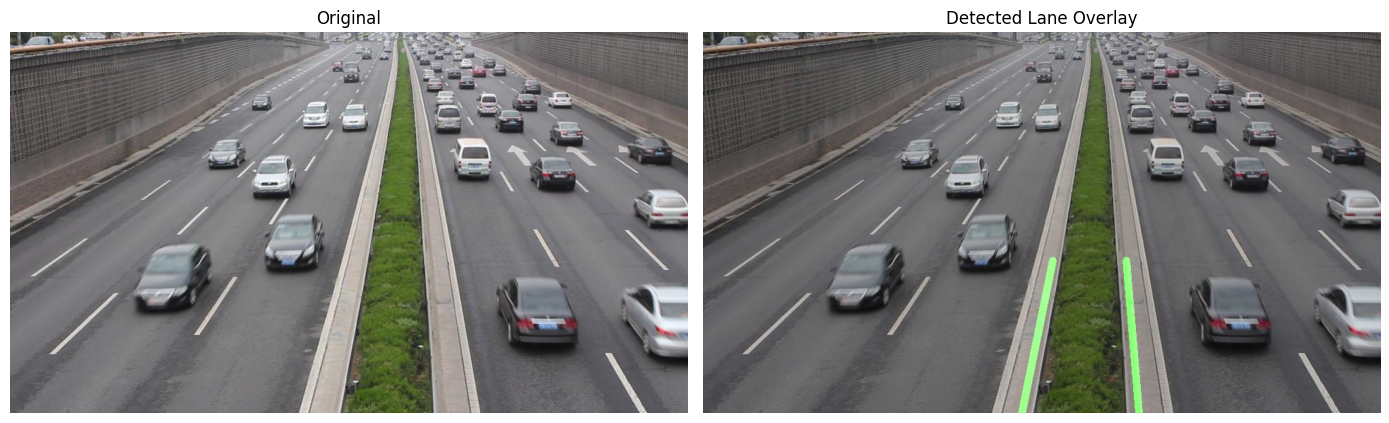

Saved output: /home/muditha/VisionProject/dataset/best/img00001_lane_detected.jpg


In [6]:
line_overlay = np.zeros_like(image_rgb)

for x1, y1, x2, y2 in lane_lines:
    cv2.line(line_overlay, (x1, y1), (x2, y2), color=(0, 255, 0), thickness=10)

result = cv2.addWeighted(image_rgb, 0.85, line_overlay, 1.0, 0)

output_path = Path('dataset/best/img00001_lane_detected.jpg')
result_bgr = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(output_path), result_bgr)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('Detected Lane Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f'Saved output: {output_path.resolve()}')